# Wine Quality Dataset - Práctica de Preprocesamiento

El Wine Quality Dataset presenta:
- Pocos datos faltantes (~0.1%)
- Principalmente variables numéricas
- Outliers manejables
- Dominio familiar (vino)
- Tamaño moderado de datos

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Manejo de advertencias
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('default')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Exploración Inicial

**Objetivo:** Entender la estructura básica del dataset

In [14]:
# Cargar datasets de vino
print("Cargando datasets de wine quality...")
print("="*50)

# Cargar vino rojo y blanco (son dos archivos separados)
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# Mostrar dimensiones de los datasets
print(f"Wine Red shape: {df_red.shape}")
print(f"Wine White shape: {df_white.shape}")

# Información básica de los datasets: columnas, tipos de datos, valores nulos y primeras filas
print("\nInformación de Wine Red:")
print(df_red.info())
print("\nInformación de Wine White:")
print(df_white.info())
print(f"\nWine White columns: {list(df_white.columns)}")
print(f"\nPrimeras 3 filas de wine white:")
df_white.head(3)
print(f"\nWine Red columns: {list(df_red.columns)}")
print(f"\nPrimeras 3 filas de wine red:")
print(df_red.head(3))
print(f"\nPrimeras 3 filas de wine white:")
print(df_white.head(3))

Cargando datasets de wine quality...
Wine Red shape: (1599, 12)
Wine White shape: (4898, 12)

Información de Wine Red:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

I

In [3]:
# Combinar ambos datasets
print("COMBINANDO DATASETS:")
print("="*30)

# Agregar columna de tipo de vino antes de combinar
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Combinar datasets en uno solo
df = pd.concat([df_red, df_white], ignore_index=True)

# Mostrar dimensiones del dataset combinado y conteo de tipos de vino
print(f"Dataset combinado shape: {df.shape}")
print(f"Tipos de vino: {df['wine_type'].value_counts()}")

# Información general del dataset combinado
print(f"\nINFORMACIÓN DEL DATASET:")
print("="*40)
df.info()

COMBINANDO DATASETS:
Dataset combinado shape: (6497, 13)
Tipos de vino: wine_type
white    4898
red      1599
Name: count, dtype: int64

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type   

In [15]:
# Estadísticas descriptivas del dataset combinado
print("ESTADÍSTICAS DESCRIPTIVAS:")
print("="*40)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 2. Análisis de Calidad del Vino

**Objetivo:** Entender la distribución de la variable target (quality)

ANÁLISIS DE LA CALIDAD DEL VINO:
Distribución de calidad del vino:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


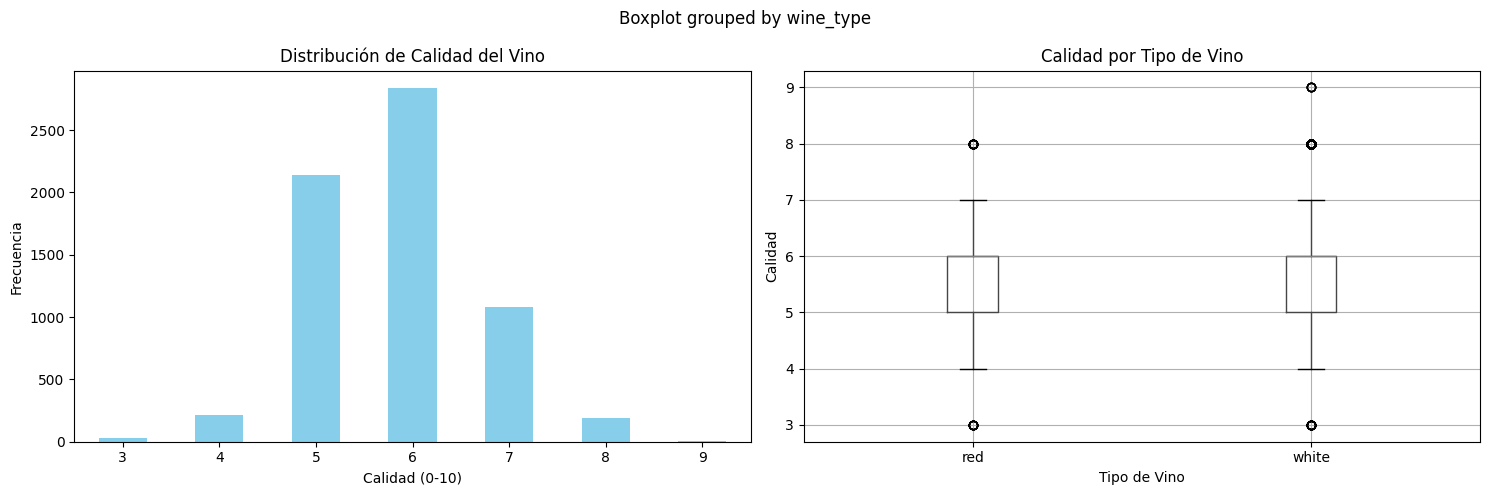

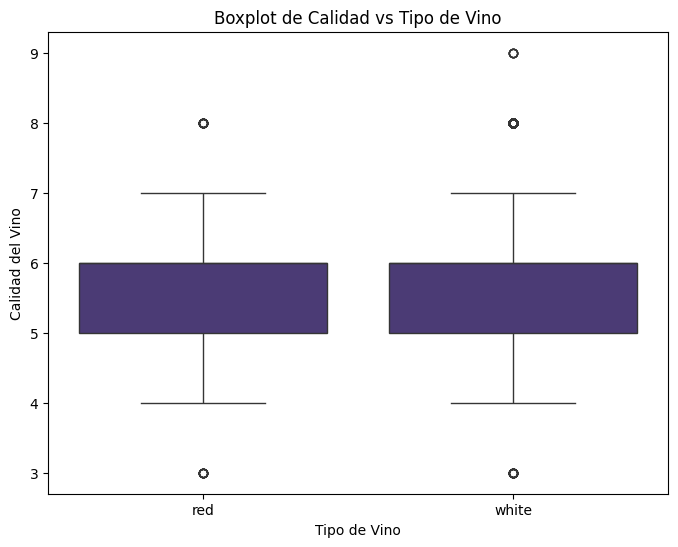


Estadísticas de calidad del vino:
Media: 5.82
Mediana: 6.00
Desviación estándar: 0.87
Rango: 3 - 9


In [16]:
# Análisis de la variable target 'quality'
print("ANÁLISIS DE LA CALIDAD DEL VINO:")
print("="*40)

# Distribución de calidad del vino, conteo por cada valor de calidad (0-10)
quality_counts = df['quality'].value_counts().sort_index()
print(f"Distribución de calidad del vino:")
print(quality_counts)

# Gráfico de distribución de calidad y boxplot por tipo de vino 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras de distribución de calidad 
quality_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribución de Calidad del Vino')
ax1.set_xlabel('Calidad (0-10)')
ax1.set_ylabel('Frecuencia')
ax1.tick_params(axis='x', rotation=0)

# Distribución por tipo de vino 
df.boxplot(column='quality', by='wine_type', ax=ax2)
ax2.set_title('Calidad por Tipo de Vino')
ax2.set_xlabel('Tipo de Vino')
ax2.set_ylabel('Calidad')

plt.tight_layout()
plt.show()

# Otra forma de visualizar la calidad del vino
plt.figure(figsize=(8, 6))
sns.boxplot(x='wine_type', y='quality', data=df)
plt.title('Boxplot de Calidad vs Tipo de Vino')
plt.xlabel('Tipo de Vino')
plt.ylabel('Calidad del Vino')
plt.show()

# Estadísticas de calidad del vino: media, mediana, desviación estándar, rango
print(f"\nEstadísticas de calidad del vino:")
print(f"Media: {df['quality'].mean():.2f}")
print(f"Mediana: {df['quality'].median():.2f}")
print(f"Desviación estándar: {df['quality'].std():.2f}")
print(f"Rango: {df['quality'].min()} - {df['quality'].max()}")

## 3. Detección de Datos Faltantes

**Objetivo:** Verificar si hay datos faltantes y cómo manejarlos

In [17]:
# Verificar datos faltantes en el dataset combinado
print("ANÁLISIS DE DATOS FALTANTES:")
print("="*40)

# Cálculo de valores faltantes y porcentaje: isnull().sum()
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

# Crear DataFrame para mostrar resultados: 'Columna', 'Valores Faltantes', 'Porcentaje'
missing_df = pd.DataFrame({
    'Columna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Porcentaje': missing_percentage.values
})

# Mostrar columnas con datos faltantes > 0
print("Columnas con datos faltantes:")
print(missing_df[missing_df['Valores Faltantes'] > 0])

# Resumen de datos faltantes
# Mostrar porcentaje de datos faltantes
print("Porcentaje de datos faltantes por columna:")
print(missing_df[missing_df['Valores Faltantes'] > 0].set_index('Columna')['Porcentaje'])

# Con un if resumir si hay o no datos faltantes
if missing_data.sum() == 0:
    print("\n✅ ¡Excelente! No hay datos faltantes en este dataset.")
    print("Esto simplifica mucho nuestro trabajo de preprocesamiento.")
else:
    print(f"\nTotal de valores faltantes: {missing_data.sum()}")

ANÁLISIS DE DATOS FALTANTES:
Columnas con datos faltantes:
Empty DataFrame
Columns: [Columna, Valores Faltantes, Porcentaje]
Index: []
Porcentaje de datos faltantes por columna:
Series([], Name: Porcentaje, dtype: float64)

✅ ¡Excelente! No hay datos faltantes en este dataset.
Esto simplifica mucho nuestro trabajo de preprocesamiento.


## 4. Análisis de Correlaciones

**Objetivo:** Entender relaciones entre variables

MATRIZ DE CORRELACIÓN:


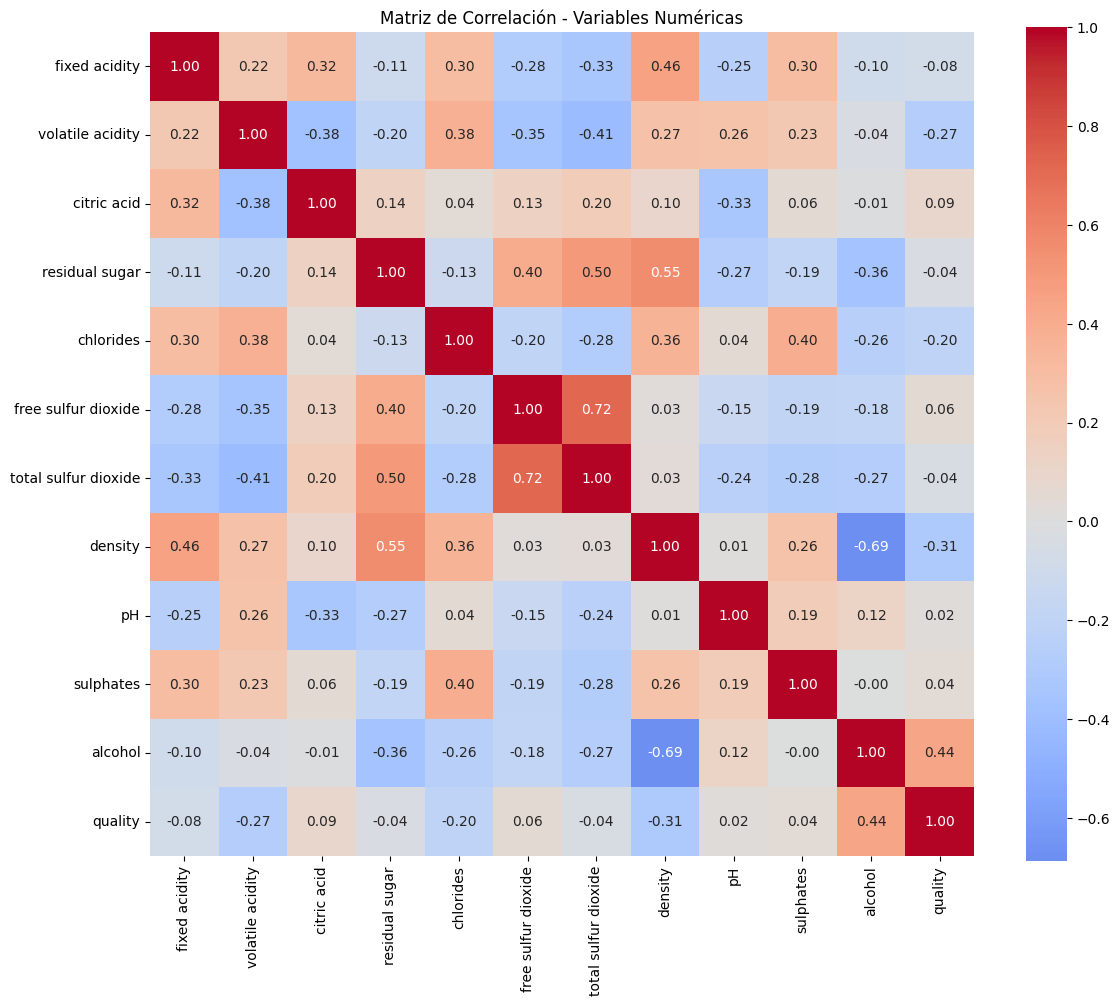


Correlaciones más fuertes con quality:
1. alcohol: 0.444
2. density: 0.306
3. volatile acidity: 0.266
4. chlorides: 0.201
5. citric acid: 0.086


In [18]:
# Calcular matriz de correlación y visualizarla
print("MATRIZ DE CORRELACIÓN:")
print("="*30)

# Seleccionar solo variables numéricas para correlación: select_dtypes(include=[np.number])
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr() # Calcular matriz de correlación

# Visualizar correlación con un heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# Encontrar las correlaciones más fuertes con quality y mostrarlas ordenadas: abs().sort_values(ascending=False)
quality_corr = correlation_matrix['quality'].abs().sort_values(ascending=False)
print(f"\nCorrelaciones más fuertes con quality:")
print("="*45)
# Mostrar las 5 características más correlacionadas con quality
for i, (feature, corr) in enumerate(quality_corr.head(6).items()):
    if feature != 'quality':
        print(f"{i}. {feature}: {corr:.3f}")

## 5. Detección de Outliers

**Objetivo:** Identificar y entender los outliers usando el método IQR

ANÁLISIS DE OUTLIERS:

alcohol:
  Outliers: 3 (0.0%)
  Rango normal: [6.80, 14.00]

volatile acidity:
  Outliers: 377 (5.8%)
  Rango normal: [-0.02, 0.66]

sulphates:
  Outliers: 191 (2.9%)
  Rango normal: [0.17, 0.85]

total sulfur dioxide:
  Outliers: 10 (0.2%)
  Rango normal: [-41.50, 274.50]


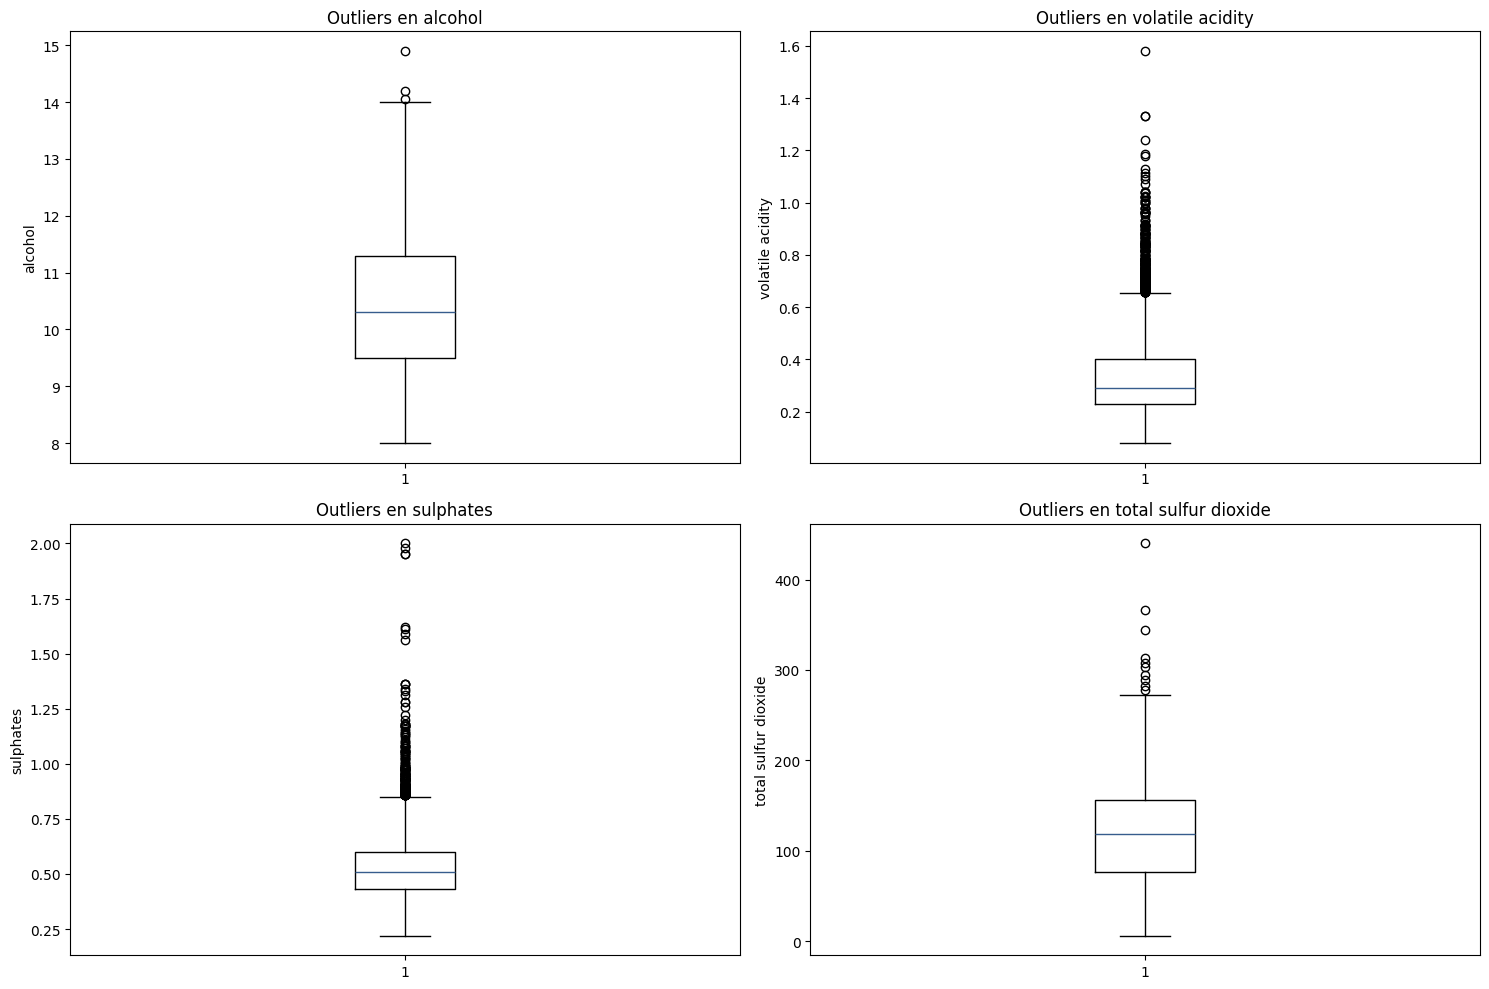


RESUMEN DE OUTLIERS:
alcohol: 3 outliers (0.0%)
volatile acidity: 377 outliers (5.8%)
sulphates: 191 outliers (2.9%)
total sulfur dioxide: 10 outliers (0.2%)


In [19]:
# Los outliers son datos que se alejan significativamente del resto de los datos.
# Pueden afectar negativamente a los modelos de machine learning.
# Creamos una función para detectar outliers usando IQR
# IRQ: Interquartile Range (Rango Intercuartílico), consiste en calcular 
# el rango entre el primer cuartil (Q1) y el tercer cuartil (Q3).
def detect_outliers_iqr(df, column):
    """Detecta outliers usando el método IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Analizar outliers en las principales características
print("ANÁLISIS DE OUTLIERS:")
print("="*30)

# Características clave a analizar basadas en correlación con quality
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide']
outlier_summary = {}

# Configurar subplots para visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Analizar cada característica creando un bucle que reutilice la función detect_outliers_iqr
# Usaremos un bucle para evitar repetir código
for idx, feature in enumerate(key_features):
    if feature in df.columns:
        outliers, lower, upper = detect_outliers_iqr(df, feature)
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_summary[feature] = {
            'count': outlier_count,
            'percentage': outlier_percentage,
            'bounds': (lower, upper)
        }
        
        print(f"\n{feature}:")
        print(f"  Outliers: {outlier_count} ({outlier_percentage:.1f}%)")
        print(f"  Rango normal: [{lower:.2f}, {upper:.2f}]")
        
        # Visualizar el boxplot de la característica con outliers
        axes[idx].boxplot(df[feature])
        axes[idx].set_title(f'Outliers en {feature}')
        axes[idx].set_ylabel(feature)
# Ajustar el layout y mostrar la figura
plt.tight_layout()
plt.show()

# Resumen de outliers encontrados
print(f"\nRESUMEN DE OUTLIERS:")
print("="*25)
# Usaremos un bucle para mostrar el resumen: .items()
for feature, info in outlier_summary.items():
    print(f"{feature}: {info['count']} outliers ({info['percentage']:.1f}%)")

## 6. Feature Engineering Básico

**Objetivo:** Crear nuevas características útiles para el modelo

CREANDO NUEVAS CARACTERÍSTICAS:
Categorías de calidad creadas:
quality_category
medium    3915
low       2384
high       198
Name: count, dtype: int64

Ratio de acidez creado

Nuevas características creadas: ['quality_category', 'acidity_ratio', 'high_alcohol']
Forma del dataset: (6497, 16)


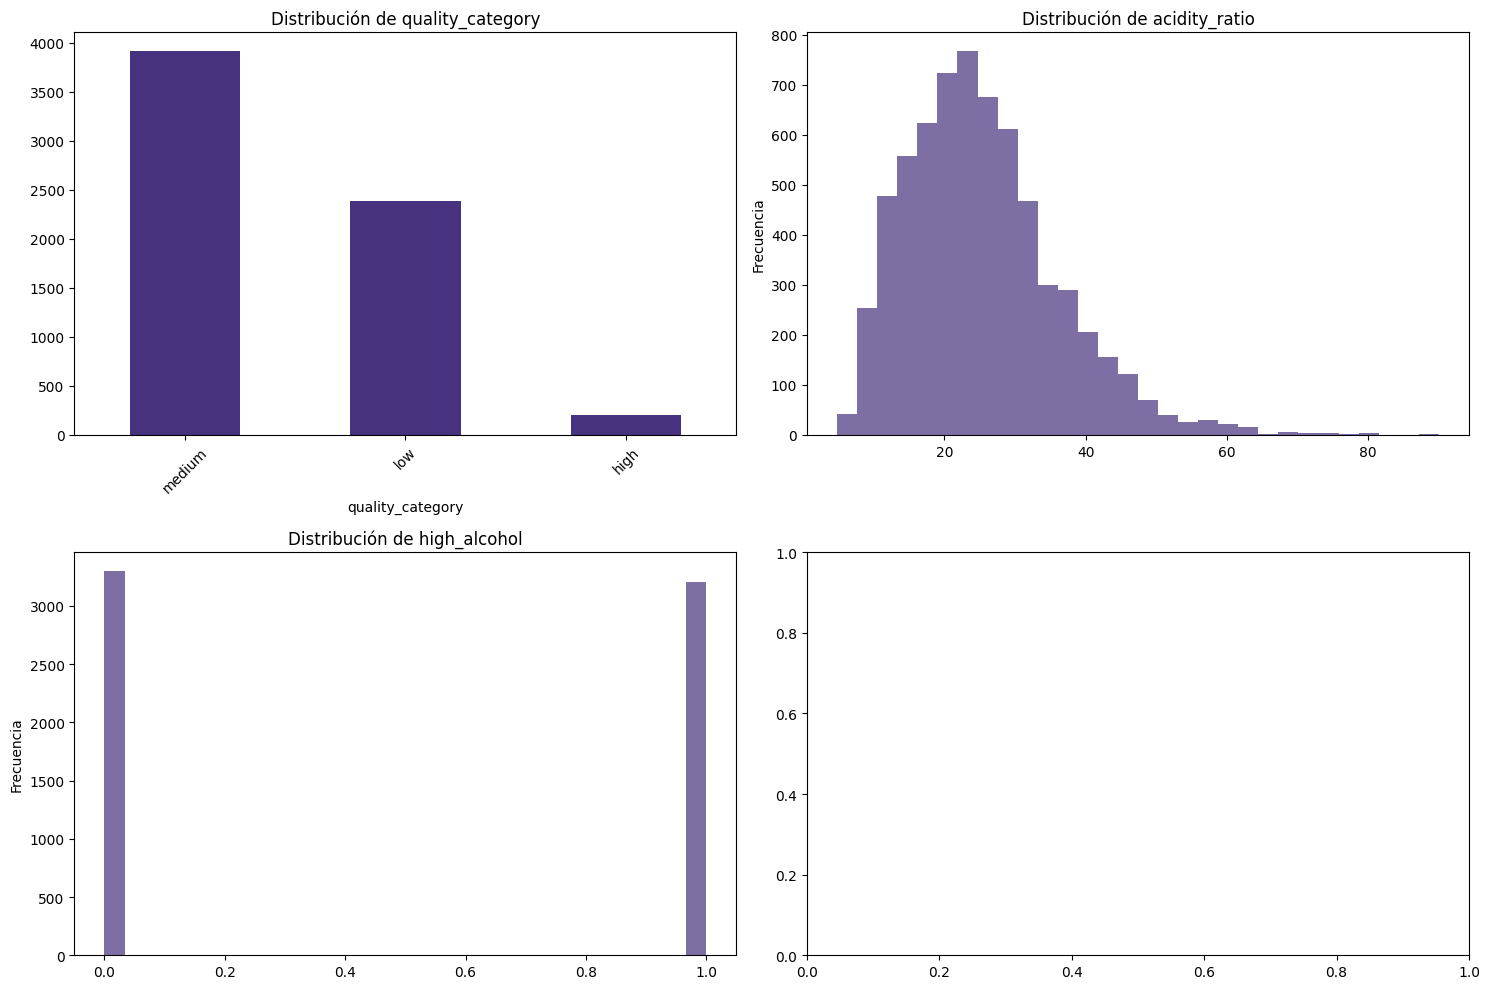

In [20]:
# Crear nuevas características basadas en las existentes
print("CREANDO NUEVAS CARACTERÍSTICAS:")
print("="*40)

# 1. Categorizar la calidad (para clasificación). 
# Crearemos una nueva columna 'quality_category' con tres categorías: 'low', 'medium', 'high'
df['quality_category'] = df['quality'].apply(
    lambda x: 'low' if x <= 5 else 'medium' if x <= 7 else 'high'
)

# Mostrar distribución de la nueva característica, antes las contamos
quality_dist = df['quality_category'].value_counts()
print(f"Categorías de calidad creadas:")
print(quality_dist)

# 2. Ratio de acidez
# Crear una nueva característica 'acidity_ratio' como la relación entre 'fixed acidity' y 'volatile acidity'
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acidity_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    print(f"\nRatio de acidez creado")

# 3. Indicador de alcohol alto
# Crear una nueva característica binaria 'high_alcohol' indicando si el alcohol es mayor que la mediana
df['high_alcohol'] = (df['alcohol'] > df['alcohol'].median()).astype(int)

# 4. Intensidad del sabor (combinando características)
# Crear una nueva característica 'flavor_intensity' como la diferencia entre 'flavanoids' y 'nonflavanoid phenols'
if all(col in df.columns for col in ['flavanoids', 'nonflavanoid phenols']):
    df['flavor_intensity'] = df['flavanoids'] - df['nonflavanoid phenols']
    print(f"Intensidad de sabor creada")

# Mostrar nuevas características y forma del dataset
new_features = ['quality_category', 'acidity_ratio', 'high_alcohol'] 
# Si se creó flavor_intensity, la añadimos a la lista
if 'flavor_intensity' in df.columns:
    new_features.append('flavor_intensity')
# Imprimimos los resultados
print(f"\nNuevas características creadas: {new_features}")
print(f"Forma del dataset: {df.shape}")

# Visualizar nuevas características en gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel() # Aplanar el array de ejes para fácil indexación
# Usaremos un bucle para mostrar cada nueva característica
for idx, feature in enumerate(new_features[:4]):
    if feature == 'quality_category':
        df[feature].value_counts().plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Distribución de {feature}')
        axes[idx].tick_params(axis='x', rotation=45)
    else:
        axes[idx].hist(df[feature], bins=30, alpha=0.7)
        axes[idx].set_title(f'Distribución de {feature}')
        axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 7. Encoding de Variables Categóricas

**Objetivo:** Convertir variables categóricas a formato numérico

In [21]:
# Analizar variables categóricas
print("ANÁLISIS DE VARIABLES CATEGÓRICAS:")
print("="*40)

# Identificar columnas categóricas, usaremos select_dtypes y .tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'quality_category' in categorical_cols:
    categorical_cols.remove('quality_category')

# Mostrar variables categóricas y sus valores únicos
print(f"Variables categóricas: {categorical_cols}")
# Usaremos un bucle para mostrar los valores únicos
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} valores únicos")
    print(f"  Valores: {df[col].unique()}")

# Aplicar Label Encoding a wine_type, que tiene dos categorías: 'red' y 'white'
le = LabelEncoder()
df['wine_type_encoded'] = le.fit_transform(df['wine_type'])

# Mostrar el mapping de etiquetas
print(f"\nEncoding aplicado:")
wine_type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"wine_type: {wine_type_mapping}")

# Crear dummy variables para quality_category (opcional)
df_quality_dummies = pd.get_dummies(df['quality_category'], prefix='quality')
df = pd.concat([df, df_quality_dummies], axis=1)

print(f"\nDummy variables creadas para quality_category:")
print(f"Columnas: {list(df_quality_dummies.columns)}")

ANÁLISIS DE VARIABLES CATEGÓRICAS:
Variables categóricas: ['wine_type']
wine_type: 2 valores únicos
  Valores: ['red' 'white']

Encoding aplicado:
wine_type: {'red': np.int64(0), 'white': np.int64(1)}

Dummy variables creadas para quality_category:
Columnas: ['quality_high', 'quality_low', 'quality_medium']


## 8. Escalado de Variables

**Objetivo:** Normalizar las variables para mejorar el rendimiento del modelo

ANÁLISIS ANTES DEL ESCALADO:
Estadísticas de las primeras 5 variables numéricas:
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides
count       6497.000          6497.000     6497.000        6497.000   6497.000
mean           7.215             0.340        0.319           5.443      0.056
std            1.296             0.165        0.145           4.758      0.035
min            3.800             0.080        0.000           0.600      0.009
25%            6.400             0.230        0.250           1.800      0.038
50%            7.000             0.290        0.310           3.000      0.047
75%            7.700             0.400        0.390           8.100      0.065
max           15.900             1.580        1.660          65.800      0.611
Características a escalar: 13
Rangos de las variables:
  fixed acidity: [3.80, 15.90] (rango: 12.10)
  volatile acidity: [0.08, 1.58] (rango: 1.50)
  citric acid: [0.00, 1.66] (rango: 1.66)
  residual sugar: 

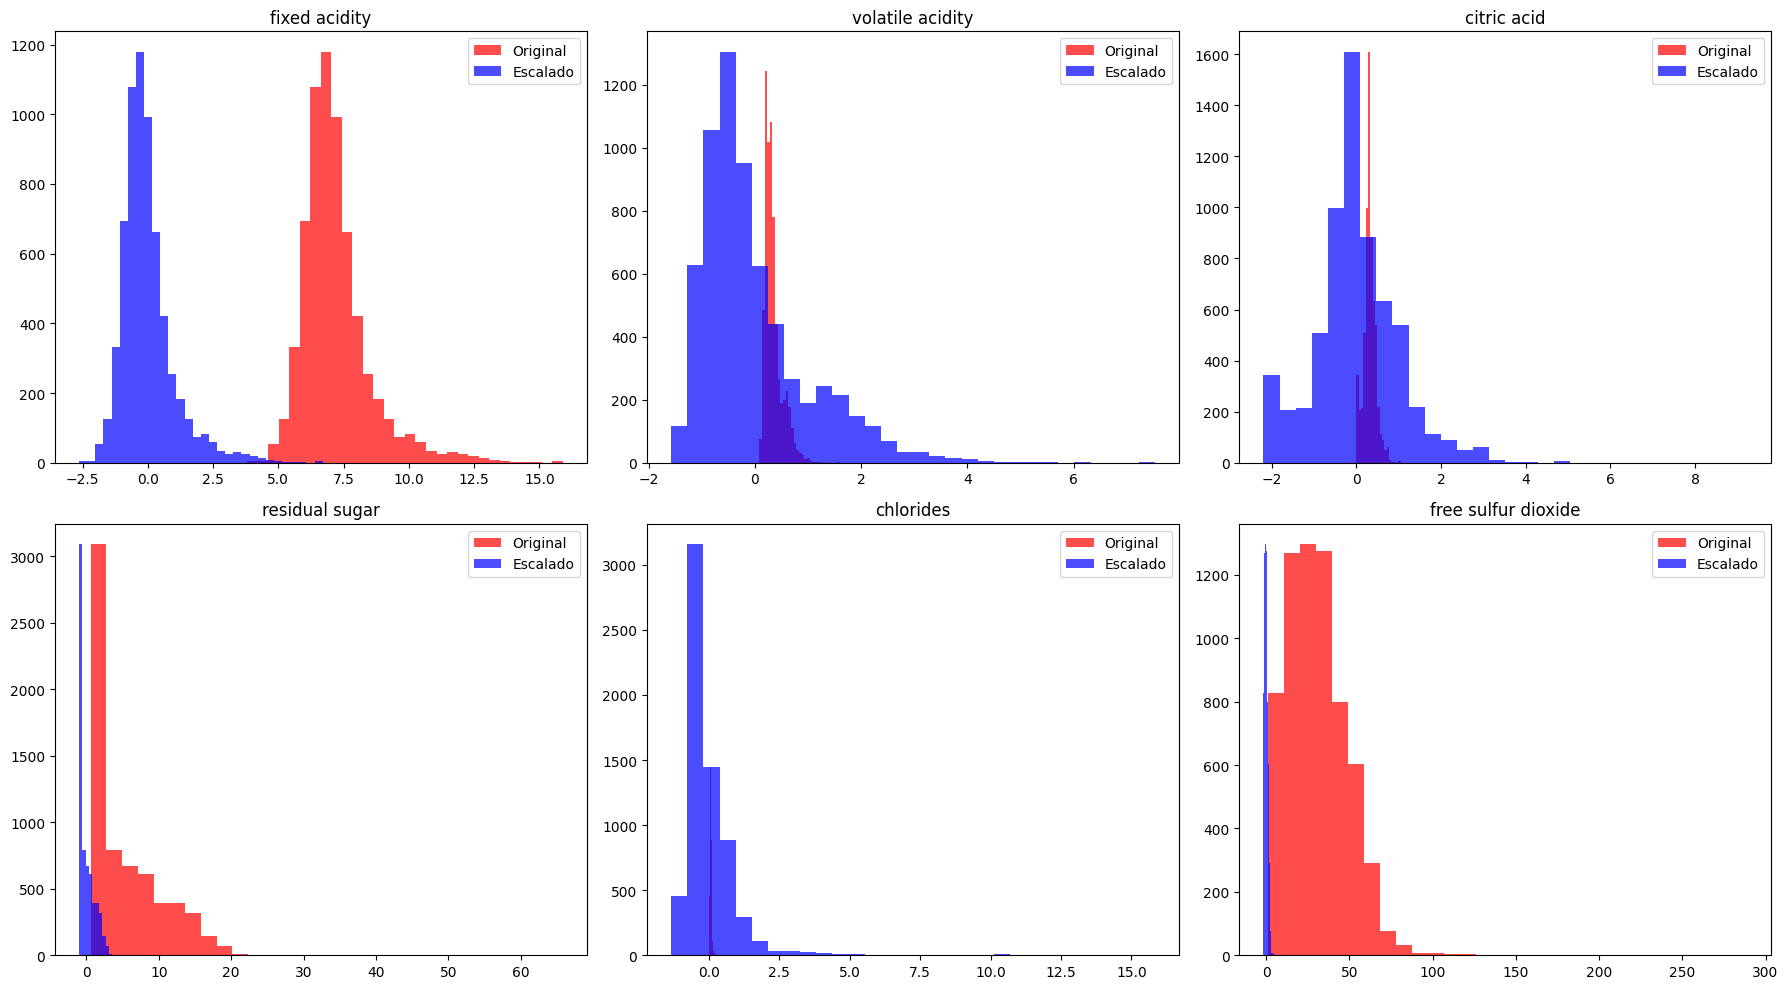

In [22]:
# Analizar rangos de variables antes del escalado
print("ANÁLISIS ANTES DEL ESCALADO:")
print("="*35)

# Identificar características numéricas excluyendo las target: select_dtypes(include=[np.number])
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
target_cols = ['quality', 'wine_type_encoded', 'quality_category']
X_features = [col for col in numerical_features if col not in target_cols]

# Mostrar estadísticas descriptivas de las primeras 5 variables
print("Estadísticas de las primeras 5 variables numéricas:")
stats = df[X_features[:5]].describe().round(3)
print(stats)
print(f"Características a escalar: {len(X_features)}")
print(f"Rangos de las variables:")
for feature in X_features[:5]:  # Mostrar solo las primeras 5
    min_val = df[feature].min()
    max_val = df[feature].max()
    print(f"  {feature}: [{min_val:.2f}, {max_val:.2f}] (rango: {max_val-min_val:.2f})")

# Aplicar StandardScaler a las características numéricas
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[X_features] = scaler.fit_transform(df[X_features])

# Analizar variables después del escalado
print(f"\nDESPUÉS DEL ESCALADO:")
print("="*25)
print("Estadísticas de las primeras 5 variables escaladas:")
scaled_stats = df_scaled[X_features[:5]].describe().round(3)
print(scaled_stats)

# Visualizar efecto del escalado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Usaremos un bucle para mostrar histogramas antes y después del escalado
for idx, feature in enumerate(X_features[:6]):
    # Antes del escalado
    axes[idx].hist(df[feature], bins=30, alpha=0.7, label='Original', color='red')
    # Después del escalado
    axes[idx].hist(df_scaled[feature], bins=30, alpha=0.7, label='Escalado', color='blue')
    axes[idx].set_title(f'{feature}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 9. Preparación Final del Dataset

**Objetivo:** Crear el dataset final listo para modelado

In [23]:
# Función para preparar el dataset final
def prepare_final_dataset(df_original, df_scaled):
    """Prepara el dataset final para modelado"""
    
    # Seleccionar características para el modelo
    features_to_use = [col for col in df_scaled.columns if col not in 
                      ['wine_type', 'quality_category', 'quality']]
    
    X_final = df_scaled[features_to_use]
    y_regression = df_scaled['quality']  # Para regresión
    y_classification = df_scaled['quality_category']  # Para clasificación
    
    return X_final, y_regression, y_classification

# Preparar dataset final para modelado
X, y_reg, y_clf = prepare_final_dataset(df, df_scaled)

# Mostrar información del dataset final: shape, columnas, valores faltantes, estadísticas
print("DATASET FINAL PREPARADO:")
print("="*30)
print(f"Features shape: {X.shape}")
print(f"Target (regression) shape: {y_reg.shape}")
print(f"Target (classification) shape: {y_clf.shape}")

print(f"\nCaracterísticas finales: {list(X.columns)}")

# Verificar que no hay valores faltantes: isnull().sum().sum()
missing_final = X.isnull().sum().sum()
print(f"Valores faltantes en features finales: {missing_final}")

# Mostrar estadísticas finales: describe().round(3)
print(f"\nEstadísticas de las características finales:")
print(X.describe().round(3))

DATASET FINAL PREPARADO:
Features shape: (6497, 17)
Target (regression) shape: (6497,)
Target (classification) shape: (6497,)

Características finales: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'acidity_ratio', 'high_alcohol', 'wine_type_encoded', 'quality_high', 'quality_low', 'quality_medium']
Valores faltantes en features finales: 0

Estadísticas de las características finales:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       6497.000          6497.000     6497.000        6497.000   
mean          -0.000             0.000        0.000           0.000   
std            1.000             1.000        1.000           1.000   
min           -2.635            -1.577       -2.193          -1.018   
25%           -0.629            -0.666       -0.472          -0.766   
50%           -0.166            -0.302       -0.059         

## 10. Entrenamiento y Validación del Modelo

**Objetivo:** Validar que el preprocesamiento mejora el rendimiento

In [24]:
# Dividir datos para entrenamiento y prueba
print("DIVISIÓN DE DATOS:")
print("="*25)

# Usar train_test_split con stratify en y_reg para mantener distribución
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, stratify=y_reg
)

# Mostrar shapes y distribución de clases
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"Distribución en entrenamiento: {np.bincount(y_train.astype(int))}")
print(f"Distribución en prueba: {np.bincount(y_test.astype(int))}")

# Entrenar modelo Random Forest Regressor
print(f"\nENTRENANDO MODELO:")
print("="*25)

# Crear y entrenar el modelo Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones 
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluación del modelo usando RMSE y R²
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Imprimir resultados de la evaluación
print(f"RESULTADOS DEL MODELO:")
print("="*25)
print(f"Entrenamiento - RMSE: {train_rmse:.3f}, R²: {train_r2:.3f}")
print(f"Prueba - RMSE: {test_rmse:.3f}, R²: {test_r2:.3f}")

# Verificar overfitting, comprobando la diferencia entre R² de entrenamiento y prueba
overfitting_check = train_r2 - test_r2
print(f"\nOverfitting check: {overfitting_check:.3f}")
if overfitting_check < 0.1:
    print("✅ Modelo bien ajustado")
elif overfitting_check < 0.2:
    print("⚠️ Ligero overfitting")
else:
    print("❌ Overfitting significativo")

DIVISIÓN DE DATOS:
Entrenamiento: (5197, 17)
Prueba: (1300, 17)
Distribución en entrenamiento: [   0    0    0   24  173 1710 2269  863  154    4]
Distribución en prueba: [  0   0   0   6  43 428 567 216  39   1]

ENTRENANDO MODELO:
RESULTADOS DEL MODELO:
Entrenamiento - RMSE: 0.126, R²: 0.979
Prueba - RMSE: 0.344, R²: 0.845

Overfitting check: 0.134
⚠️ Ligero overfitting


ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS:
Top 10 características más importantes:
 1. quality_low              : 0.6638
 2. quality_medium           : 0.0583
 3. quality_high             : 0.0575
 4. alcohol                  : 0.0304
 5. total sulfur dioxide     : 0.0204
 6. acidity_ratio            : 0.0201
 7. free sulfur dioxide      : 0.0192
 8. density                  : 0.0177
 9. chlorides                : 0.0175
10. pH                       : 0.0174


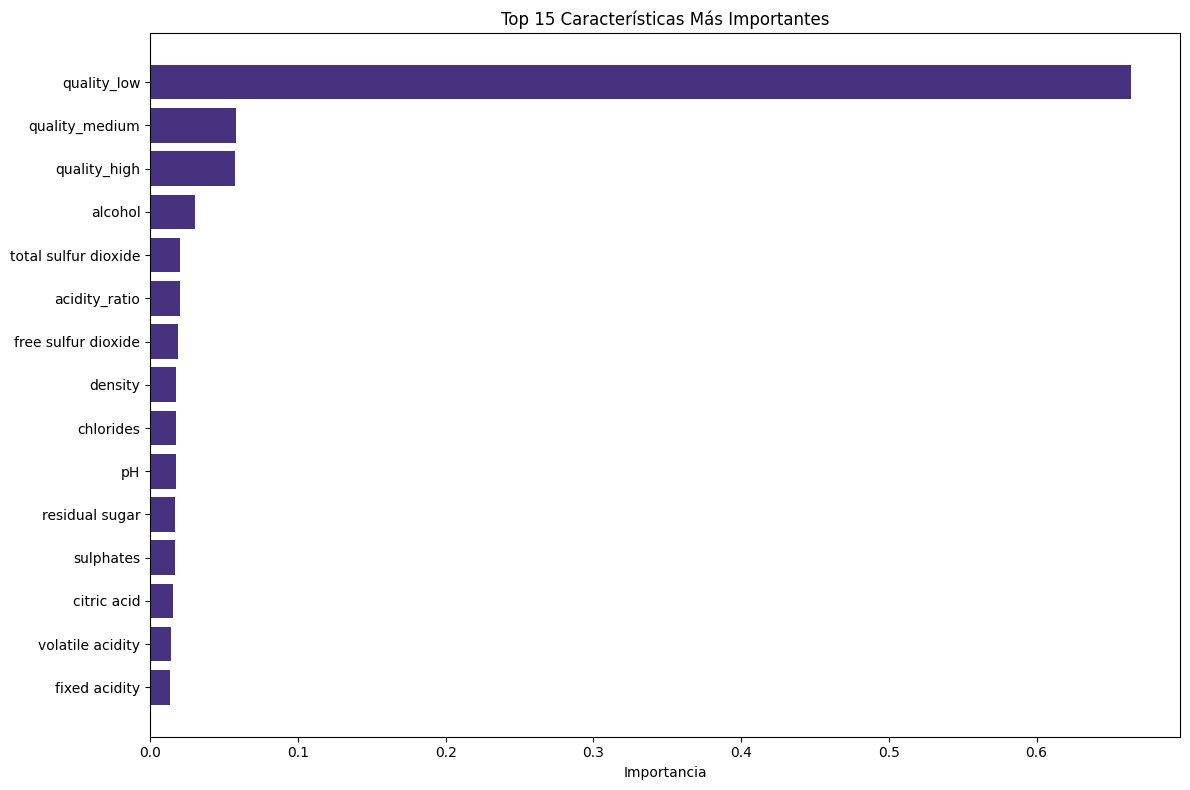

In [25]:
# Análisis de importancia de características
print("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS:")
print("="*50)

# Obtener importancia de características del modelo
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Mostrar las 10 características más importantes
print(f"Top 10 características más importantes:")
for i, (idx, row) in enumerate(feature_importance.head(10).iterrows()):
    print(f"{i+1:2d}. {row['feature']:25s}: {row['importance']:.4f}")

# Visualizar importancia
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia')
plt.title('Top 15 Características Más Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Resumen del Preprocesamiento

**Objetivo:** Consolidar todo lo aprendido

In [26]:
print("RESUMEN COMPLETO DEL PREPROCESAMIENTO:")
print("="*55)

print("\n📊 PASOS REALIZADOS:")
print("="*25)
print("1. ✅ Carga y exploración de datos")
print("2. ✅ Análisis de la variable target (quality)")
print("3. ✅ Detección de datos faltantes (ninguno encontrado)")
print("4. ✅ Análisis de correlaciones entre variables")
print("5. ✅ Detección de outliers con método IQR")
print("6. ✅ Feature engineering (4 nuevas características)")
print("7. ✅ Encoding de variables categóricas")
print("8. ✅ Escalado de variables con StandardScaler")
print("9. ✅ Preparación del dataset final")
print("10. ✅ Entrenamiento y validación del modelo")

print("\n📈 RESULTADOS OBTENIDOS:")
print("="*30)
print(f"• Dataset original: 13 características")
print(f"• Dataset final: {X.shape[1]} características")
print(f"• Nuevas características creadas: 4")
print(f"• Performance del modelo (R²): {test_r2:.3f}")
print(f"• Error del modelo (RMSE): {test_rmse:.3f}")
print(f"• Característica más importante: {feature_importance.iloc[0]['feature']}")

print("\n🎯 VENTAJAS DEL WINE QUALITY DATASET:")
print("="*45)
print("• Datos limpios (pocos valores faltantes)")
print("• Principalmente variables numéricas")
print("• Dominio familiar y fácil de interpretar")
print("• Tamaño moderado de dataset")
print("• Outliers manejables")
print("• Excelente para aprender conceptos básicos")

print(f"\n✅ ¡PREPROCESAMIENTO CORRECTO COMPLETADO!")
print("El dataset está listo para cualquier algoritmo de machine learning.")

RESUMEN COMPLETO DEL PREPROCESAMIENTO:

📊 PASOS REALIZADOS:
1. ✅ Carga y exploración de datos
2. ✅ Análisis de la variable target (quality)
3. ✅ Detección de datos faltantes (ninguno encontrado)
4. ✅ Análisis de correlaciones entre variables
5. ✅ Detección de outliers con método IQR
6. ✅ Feature engineering (4 nuevas características)
7. ✅ Encoding de variables categóricas
8. ✅ Escalado de variables con StandardScaler
9. ✅ Preparación del dataset final
10. ✅ Entrenamiento y validación del modelo

📈 RESULTADOS OBTENIDOS:
• Dataset original: 13 características
• Dataset final: 17 características
• Nuevas características creadas: 4
• Performance del modelo (R²): 0.845
• Error del modelo (RMSE): 0.344
• Característica más importante: quality_low

🎯 VENTAJAS DEL WINE QUALITY DATASET:
• Datos limpios (pocos valores faltantes)
• Principalmente variables numéricas
• Dominio familiar y fácil de interpretar
• Tamaño moderado de dataset
• Outliers manejables
• Excelente para aprender conceptos bás

## 💡 EJERCICIOS PARA PRACTICAR

### Ejercicio 1: Experimentar con Escalado
- Probar MinMaxScaler en lugar de StandardScaler
- Comparar resultados del modelo
- ¿Cuál funciona mejor para este dataset?

### Ejercicio 2: Manejo de Outliers
- Remover outliers y ver el impacto
- Aplicar transformación logarítmica a variables sesgadas
- Comparar performance del modelo

### Ejercicio 3: Más Feature Engineering
- Crear interacciones entre variables (ej: alcohol × acidity)
- Aplicar PCA para reducir dimensionalidad
- Crear características polinomiales

### Ejercicio 4: Modelos Alternativos
- Probar Linear Regression
- Experimentar con Support Vector Regression
- Comparar todos los modelos

### Ejercicio 5: Validación Cruzada
- Implementar k-fold cross validation
- Analizar estabilidad de las métricas
- Identificar el mejor modelo y parámetros